### On va essayer de soustraire les cartes temps fréquence pour montrer les différences

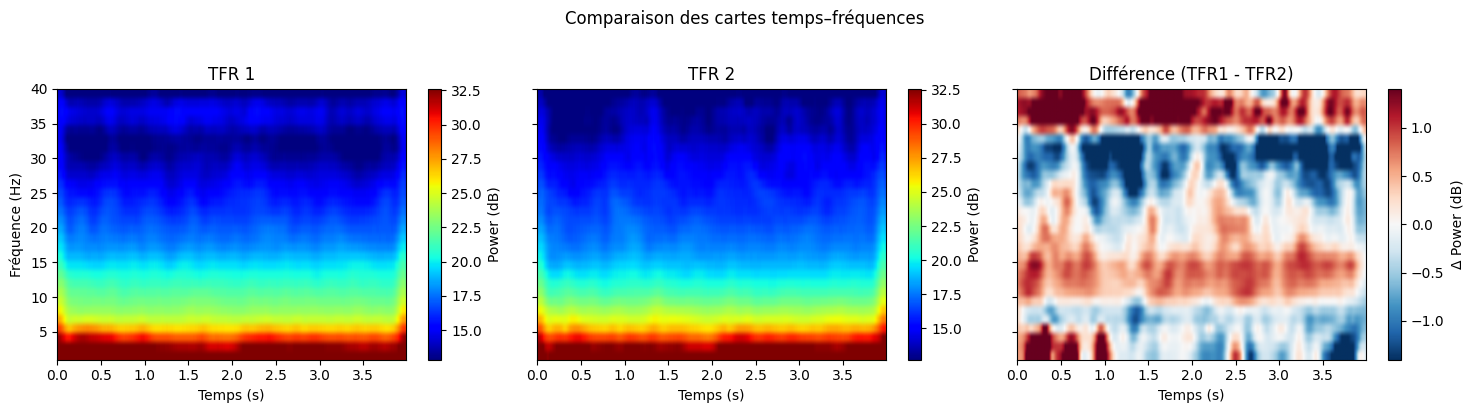

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tf1_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/group_Fp1-C3_power.npy")
tf2_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/group_Fp2-T4_power.npy")
time_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/times.npy")
freq_path = Path("../../documents/EEG/preprocessed/bipolaire/3_results_analysis/gp2/_by_patient_category/eai/REM/freqs.npy")

# Chargement 
tf1 = np.load(tf1_path)
tf2 = np.load(tf2_path)
time = np.load(time_path)
freq = np.load(freq_path)

# Alignement si dimensions différentes (rognage au min) 
f_len = min(tf1.shape[0], tf2.shape[0], len(freq))
t_len = min(tf1.shape[1], tf2.shape[1], len(time))
tf1_ = tf1[:f_len, :t_len]
tf2_ = tf2[:f_len, :t_len]
freq_ = np.asarray(freq[:f_len])
time_ = np.asarray(time[:t_len])

# Différence absolue (en dB) 
diff = tf1_ - tf2_

# Helpers d'affichage 
def robust_limits(A, p_lo=5, p_hi=95):
    A = A[np.isfinite(A)]
    if A.size == 0:
        return -1.0, 1.0
    lo, hi = np.percentile(A, [p_lo, p_hi])
    if lo == hi:
        eps = 1e-6
        return lo - eps, hi + eps
    return float(lo), float(hi)

def extent_from_axes(time_v, freq_v, Z):
    # Sécurise l'extent par rapport aux tailles affichées
    return [time_v[0], time_v[len(Z[0]) - 1], freq_v[0], freq_v[len(Z) - 1]]

# Échelles couleur
vmin1, vmax1 = robust_limits(tf1_)
vmin2, vmax2 = robust_limits(tf2_)

# Échelle symétrique centrée 0 pour la différence
lo_d, hi_d = robust_limits(diff)
vmax_d = max(abs(lo_d), abs(hi_d)) or 1e-6
vmin_d, vmax_d = -vmax_d, vmax_d

# Plot côte à côte
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

# TFR 1
im1 = axes[0].imshow(tf1_, aspect='auto', origin='lower',
                     extent=extent_from_axes(time_, freq_, tf1_),
                     cmap='jet', vmin=vmin1, vmax=vmax1)
axes[0].set_title('TFR 1')
axes[0].set_xlabel('Temps (s)')
axes[0].set_ylabel('Fréquence (Hz)')
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('Power (dB)')

# TFR 2
im2 = axes[1].imshow(tf2_, aspect='auto', origin='lower',
                     extent=extent_from_axes(time_, freq_, tf2_),
                     cmap='jet', vmin=vmin2, vmax=vmax2)
axes[1].set_title('TFR 2')
axes[1].set_xlabel('Temps (s)')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('Power (dB)')

# Différence (TFR1 - TFR2)
im3 = axes[2].imshow(diff, aspect='auto', origin='lower',
                     extent=extent_from_axes(time_, freq_, diff),
                     cmap='RdBu_r', vmin=vmin_d, vmax=vmax_d)
axes[2].set_title('Différence (TFR1 - TFR2)')
axes[2].set_xlabel('Temps (s)')
cbar3 = plt.colorbar(im3, ax=axes[2])
cbar3.set_label('Delta Power (dB)')

fig.suptitle('Comparaison des cartes temps-fréquences', y=1.02, fontsize=12)
fig.tight_layout()
plt.show()
 
# fig.savefig('tfr_compare_and_diff.png', dpi=300, bbox_inches='tight')
